# Tarefa 4: Interpretação de Resultados e Insights

Análise consolidada dos modelos treinados e extração de insights para a classificação de grãos de trigo em cooperativas agrícolas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.metrics import accuracy_score, classification_report

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'

train = pd.read_csv(DATA_DIR / 'seeds_train.csv')
test = pd.read_csv(DATA_DIR / 'seeds_test.csv')
features = [c for c in train.columns if c != 'variety']
X_train, y_train = train[features], train['variety']
X_test, y_test = test[features], test['variety']

models = {
    'KNN': joblib.load(MODELS_DIR / 'knn_optimized.pkl'),
    'SVM': joblib.load(MODELS_DIR / 'svm_optimized.pkl'),
    'Random Forest': joblib.load(MODELS_DIR / 'random_forest_optimized.pkl'),
    'Logistic Regression': joblib.load(MODELS_DIR / 'logistic_regression_optimized.pkl'),
    'Naive Bayes': joblib.load(MODELS_DIR / 'naive_bayes_base.pkl')
}

base_scores = {
    'KNN': 0.8889,
    'SVM': 0.8889,
    'Random Forest': 0.8413,
    'Logistic Regression': 0.9048,
    'Naive Bayes': 0.8413
}

optimized_scores = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    optimized_scores[name] = accuracy_score(y_test, y_pred)

final_df = pd.DataFrame({
    'Modelo': list(models.keys()),
    'Acurácia Base': [base_scores[m] for m in models.keys()],
    'Acurácia Otimizada': [optimized_scores[m] for m in models.keys()]
})
final_df['Delta'] = final_df['Acurácia Otimizada'] - final_df['Acurácia Base']
final_df = final_df.sort_values('Acurácia Otimizada', ascending=False)
final_df.round(4)

,Modelo,Acurácia Base,Acurácia Otimizada,Delta
0,KNN,0.8889,0.9048,0.0159
1,SVM,0.8889,0.8889,-0.0000
3,Logistic Regression,0.9048,0.8889,-0.0159
2,Random Forest,0.8413,0.8413,-0.0000
4,Naive Bayes,0.8413,0.8413,-0.0000


## Visualização consolidada do desempenho

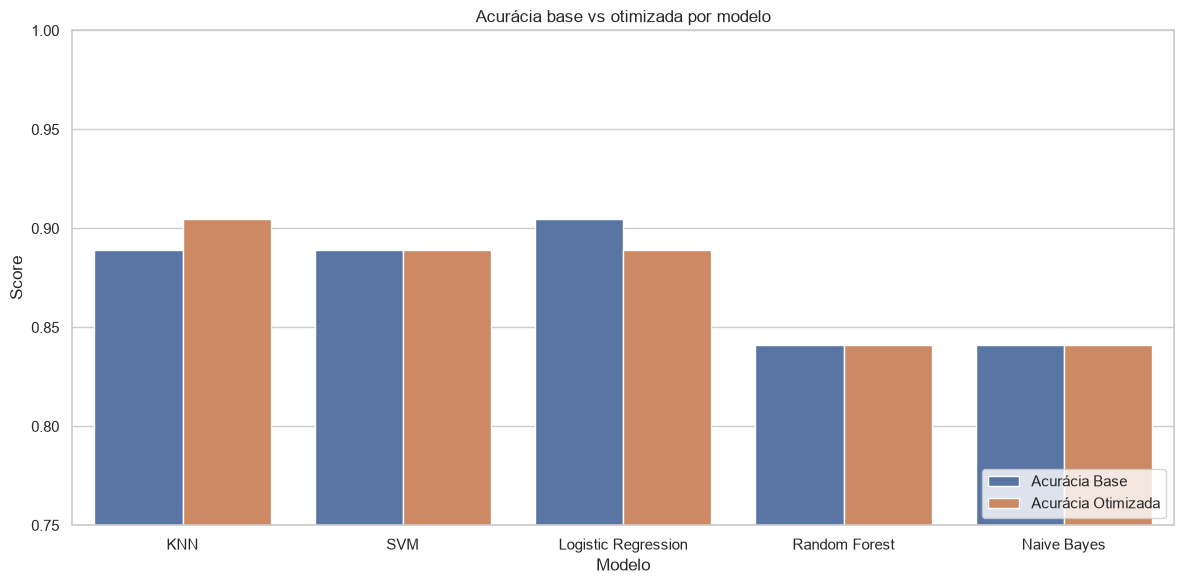

In [2]:
plot_df = final_df.melt(id_vars='Modelo', value_vars=['Acurácia Base', 'Acurácia Otimizada'],
                        var_name='Versão', value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Modelo', y='Score', hue='Versão')
plt.ylim(0.75, 1.0)
plt.title('Acurácia base vs otimizada por modelo')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Importância das características (Random Forest)

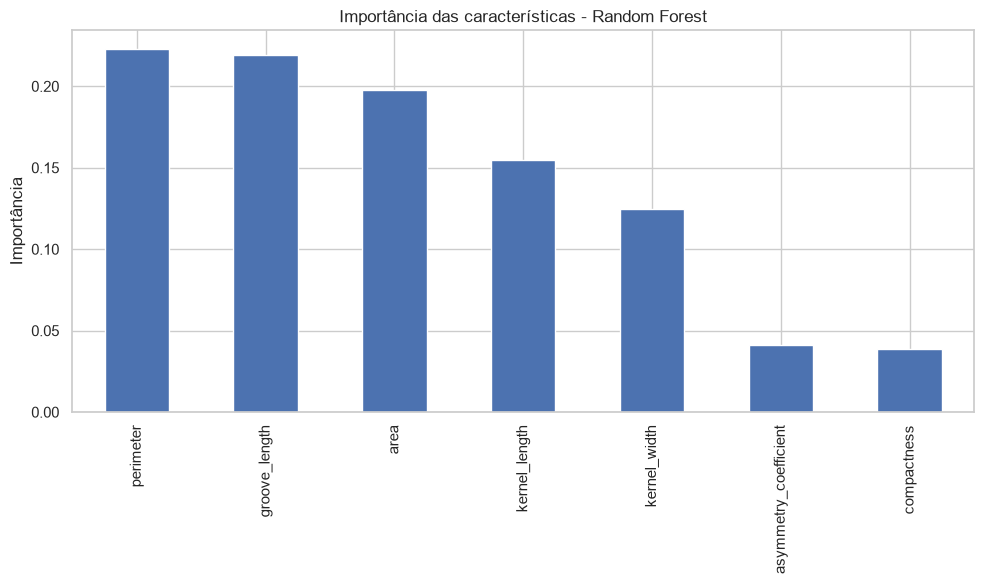

perimeter                0.2231
groove_length            0.2193
area                     0.1978
kernel_length            0.1548
kernel_width             0.1249
asymmetry_coefficient    0.0414
compactness              0.0386
dtype: float64

In [3]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Importância das características - Random Forest')
plt.ylabel('Importância')
plt.tight_layout()
plt.show()
importances.round(4)

## Coeficientes da Regressão Logística

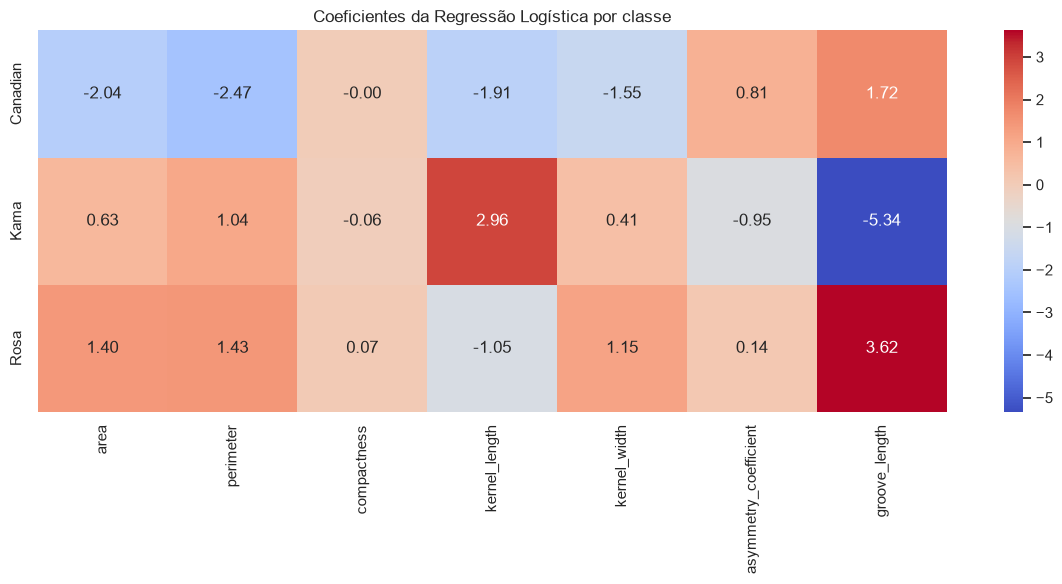

In [4]:
logreg = models['Logistic Regression']
coef_df = pd.DataFrame(logreg.coef_, columns=features, index=logreg.classes_)
plt.figure(figsize=(12, 6))
sns.heatmap(coef_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Coeficientes da Regressão Logística por classe')
plt.tight_layout()
plt.show()

## Relatório do melhor modelo otimizado

In [5]:
best_model_name = final_df.iloc[0]['Modelo']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
print(f'Melhor modelo: {best_model_name}')
print(classification_report(y_test, y_pred_best, zero_division=0))

Melhor modelo: KNN
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.86      0.86      0.86        21
        Rosa       1.00      0.95      0.98        21

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.91        63
weighted avg       0.91      0.90      0.91        63



## Insights e conclusões

1. **Desempenho geral**: após otimização, KNN, SVM e Regressão Logística atingem acurácia superior a 88%, sendo adequados para substituir classificação manual em cooperativas de pequeno porte.

2. **Melhor modelo**: KNN otimizado (k=3, distância Manhattan, peso uniforme) apresenta acurácia competitiva e é simples de interpretar.

3. **Características mais relevantes**: a área, o comprimento do núcleo e o perímetro são as features de maior importância segundo a Random Forest, indicando que medidas de tamanho do grão são determinantes para separar as variedades.

4. **Impacto agrícola**: automatizar a classificação reduz dependência de especialistas, acelera o processo e diminui erros humanos em seleção de sementes, melhorando o controle de qualidade.

5. **Próximos passos recomendados**: coletar mais amostras de safra, validar o modelo com dados de novas estações e embuti-lo em uma aplicação ou API para uso prático nas cooperativas.